<a href="https://www.kaggle.com/code/salemali7/carprice-prediction-machinelearning-models?scriptVersionId=324818167" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

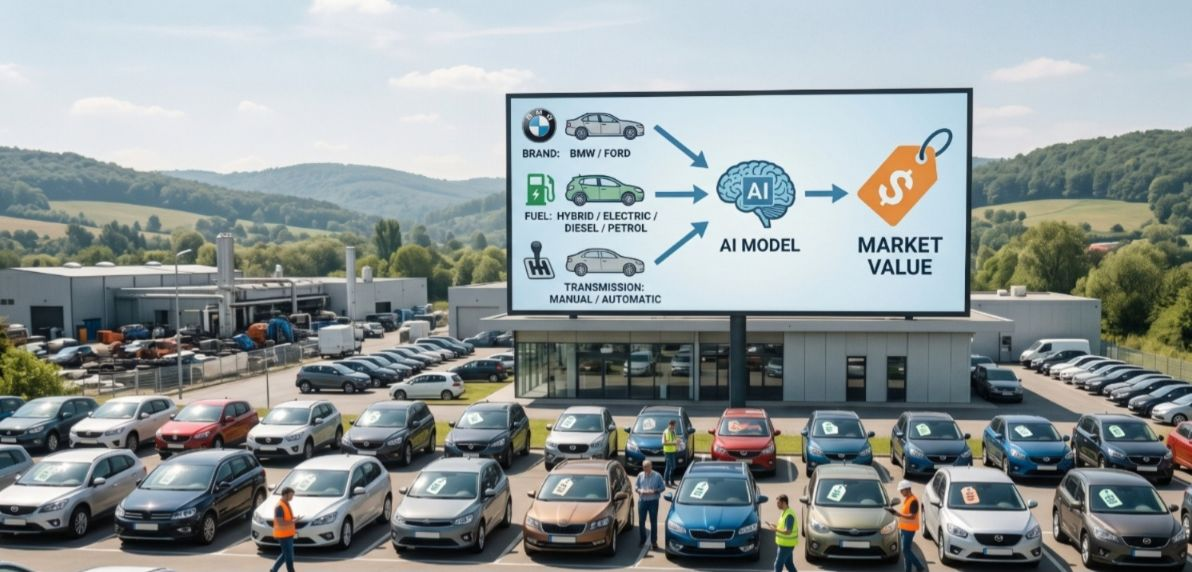

# Car Price Prediction and Vehicle Specifications
**Auther:** SalemAli

This project uses machine learning to predict car prices based on various technical specifications. <br>
By analyzing features like brand, fuel type, and transmission, the goal is to develop a reliable model that can estimate a vehicle's market value.

## The Dataset
The dataset contains a variety of vehicle details. To make the data "machine-readable," we’ve mapped categorical text data into numerical formats:

* **Target Variable:** `Price` (what we are trying to predict).
* **Key Categorical Features:** * `Transmission`: (Manual vs. Automatic)
    * `Fuel_Type`: (Hybrid, Electric, Diesel, Petrol)
    * `Brand`: (Ford, Hyundai, BMW, Honda, Tesla, Toyota)
* **Other Predictors:** Beyond these, the models utilize additional numerical features like mileage, manufacturing year, and engine specifications to improve accuracy.

## What this code does:
The pipeline follows a standard machine learning workflow to ensure we get the best possible results:

1.  **Data Cleaning & Preprocessing:** We remove irrelevant columns like `Car_ID` and convert categorical text strings into numbers so our algorithms can understand them.
2.  **Exploratory Data Analysis:** We use a correlation heatmap to visualize how strongly each feature relates to the car's price.
3.  **Model Training:** We split our data into training and testing sets to evaluate performance fairly. We then train three different models:
    * **Linear Regression**
    * **Decision Tree Regressor**
    * **Random Forest Regressor**
4.  **Performance Evaluation:** We compare the models using metrics like **MSE** (Mean Squared Error), **RMSE** (Root Mean Squared Error), and the **R² score** to see how well they capture the price patterns.
5. **Print 10 values:** We manually compare the predicted values against the actual prices to spot-check the model's accuracy on unseen data.
6.  **Feature Importance:** Finally, we extract and visualize which vehicle specifications actually drive the price up or down, giving us a clearer look into what buyers (and our models) care about most.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from imblearn.over_sampling import SMOTE,BorderlineSMOTE,ADASYN
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error


# help(RandomForestClassifier)

In [2]:
df=pd.read_csv('/kaggle/input/datasets/ihasan88/car-price-prediction-and-vehicle-specifications/car_price_dataset.csv')
df.head(9)

,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
0,1,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,2,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60
2,3,BMW,2008,2.2,Diesel,Manual,74672,3,2,333,41894.40
3,4,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381,54046.70
4,5,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290,38010.35
5,6,Honda,2023,3.5,Petrol,Automatic,94110,2,4,173,54182.50
6,7,BMW,2016,2.3,Petrol,Manual,7810,2,3,267,52140.50
7,8,BMW,2022,3.9,Petrol,Automatic,195932,4,1,369,61707.40
8,9,BMW,2010,2.6,Electric,Manual,76688,3,1,238,44992.60


In [3]:
print('The Dataset Size: ',df.shape)

The Dataset Size:  (2000, 11)


In [4]:
# df.isnull().sum() #Good, There no Missing values

In [5]:
# convert strings to Numbers
print(df['Transmission'].unique())
df['Transmission']=df['Transmission'].map({'Manual':1,'Automatic':2})
print(df['Transmission'].unique())


print(df['Fuel_Type'].unique())
df['Fuel_Type']=df['Fuel_Type'].map({'Hybrid':1, 'Electric':2, 'Diesel':3, 'Petrol':4})
print(df['Fuel_Type'].unique())

print(df['Brand'].unique())
df['Brand']=df['Brand'].map({'Ford':1, 'Hyundai':2, 'BMW':3, 'Honda':4,'Tesla':5,'Toyota':6})
print(df['Brand'].unique())

['Manual' 'Automatic']
[1 2]
['Hybrid' 'Electric' 'Diesel' 'Petrol']
[1 2 3 4]
['Ford' 'Hyundai' 'BMW' 'Honda' 'Tesla' 'Toyota']
[1 2 3 4 5 6]


In [6]:
X=df.drop(['Price','Car_ID'],axis=1)
Y=df['Price']
xtrain,xtest,ytrain,ytest=train_test_split(X,Y, test_size=0.3,random_state=42)
Y.mean()

np.float64(46169.50767499999)

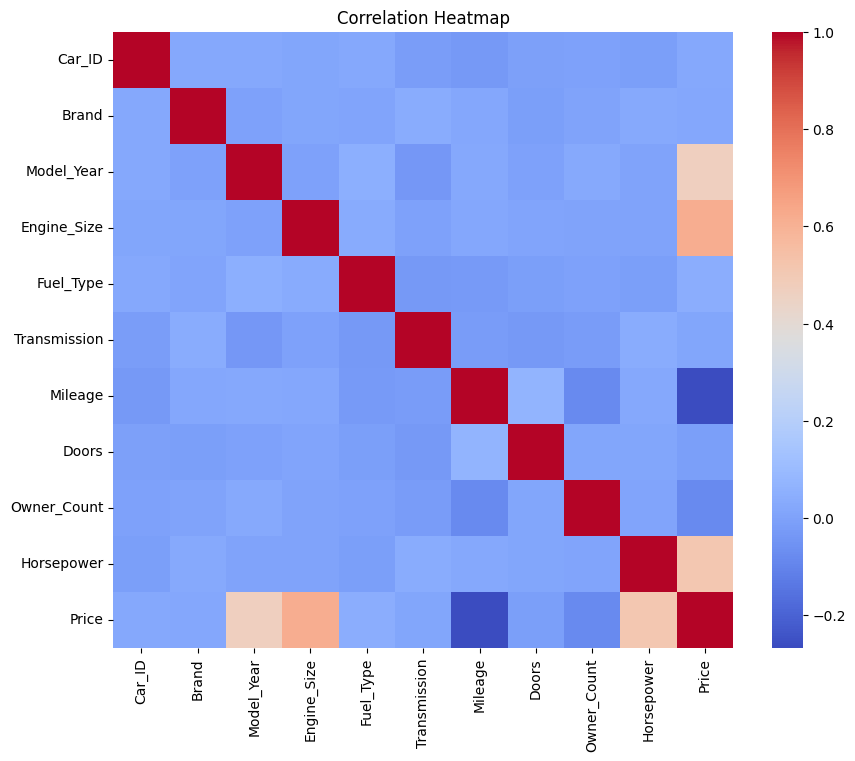

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Time := 0.03  seconds


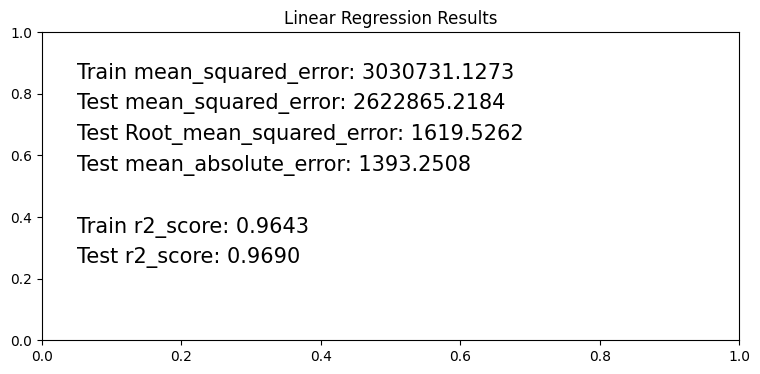


Linear Regression Results

The Predicted results of Unseen Data: 

---------------------------------------|
Predicted: 42322.45 , Actual: 43212.35
Predicted: 44200.31 , Actual: 46083.40
Predicted: 54122.31 , Actual: 52442.80
Predicted: 52663.94 , Actual: 52911.10
Predicted: 53910.42 , Actual: 56364.50
Predicted: 48071.52 , Actual: 48364.90
Predicted: 47328.74 , Actual: 49984.80
Predicted: 61439.91 , Actual: 61124.75
Predicted: 38606.60 , Actual: 35864.65
Predicted: 52254.66 , Actual: 53218.25
Predicted: 43661.91 , Actual: 44945.60
Predicted: 43976.25 , Actual: 42420.00
Predicted: 51189.79 , Actual: 51639.10
Predicted: 41696.10 , Actual: 43739.70
Predicted: 41192.24 , Actual: 40373.85
Predicted: 45610.75 , Actual: 45759.75
Predicted: 50752.82 , Actual: 51960.50
Predicted: 63612.33 , Actual: 65408.15
Predicted: 41201.93 , Actual: 39111.60
Predicted: 51071.54 , Actual: 49817.80


In [8]:
from sklearn.preprocessing import StandardScaler
starttime=time.perf_counter()

# ------------------------------------------]||

scaler = StandardScaler()
xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)

modelLR=LinearRegression()
modelLR.fit(xtrain_scaled,ytrain)

train_predictions = modelLR.predict(xtrain_scaled)
test_predictions =modelLR.predict(xtest_scaled)

train_mse = mean_squared_error(ytrain, train_predictions)
test_mse = mean_squared_error(ytest, test_predictions)
test_rmse=np.sqrt(test_mse)
test_mae = mean_absolute_error(ytest, test_predictions)
train_r2 = r2_score(ytrain, train_predictions)
test_r2 = r2_score(ytest, test_predictions)

print('Time :=',format(time.perf_counter()-starttime,'.2f'),' seconds')
plt.figure(figsize=(9,4))
plt.title('Linear Regression Results')
plt.text(0.05, 0.85, f"Train mean_squared_error: {train_mse  :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.75, f"Test mean_squared_error: { test_mse :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.65, f"Test Root_mean_squared_error: {test_rmse  :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.55, f"Test mean_absolute_error: { test_mae :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.35, f"Train r2_score: {train_r2 :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.25, f"Test r2_score: {test_r2 :.4f}", fontsize=15, ha='left')
plt.show()


print('\nLinear Regression Results')
print('\nThe Predicted results of Unseen Data: \n')
print('---------------------------------------|')
for i in range(20):
    print('Predicted:', format(test_predictions[i],'.2f'), ', Actual:',  format(ytest.iloc[i],'.2f'))

Time := 0.02  seconds


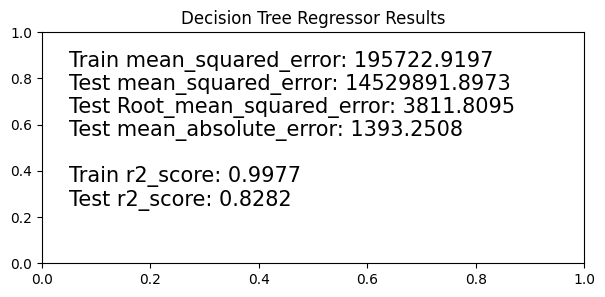


Decision Tree Regressor Results

The Predicted results of Unseen Data: 

---------------------------------------|
Predicted: 41517.18 , Actual: 43212.35
Predicted: 41499.75 , Actual: 46083.40
Predicted: 50674.38 , Actual: 52442.80
Predicted: 50321.45 , Actual: 52911.10
Predicted: 51425.00 , Actual: 56364.50
Predicted: 48810.85 , Actual: 48364.90
Predicted: 49362.45 , Actual: 49984.80
Predicted: 60625.94 , Actual: 61124.75
Predicted: 37628.35 , Actual: 35864.65
Predicted: 53673.65 , Actual: 53218.25
Predicted: 47871.90 , Actual: 44945.60
Predicted: 45647.95 , Actual: 42420.00
Predicted: 55491.75 , Actual: 51639.10
Predicted: 47006.40 , Actual: 43739.70
Predicted: 37807.85 , Actual: 40373.85
Predicted: 42257.70 , Actual: 45759.75
Predicted: 51228.90 , Actual: 51960.50
Predicted: 60625.94 , Actual: 65408.15
Predicted: 37886.12 , Actual: 39111.60
Predicted: 54438.50 , Actual: 49817.80


In [9]:
starttime=time.perf_counter()

modelD=DecisionTreeRegressor(
                              max_depth=11,
                              random_state=41,
                              min_samples_split=2,
    )

modelD.fit(xtrain,ytrain)
train_predictions = modelD.predict(xtrain)
test_predictions =modelD.predict(xtest)

train_mse = mean_squared_error(ytrain, train_predictions)
test_mse = mean_squared_error(ytest, test_predictions)
test_rmse=np.sqrt(test_mse)
train_r2 = r2_score(ytrain, train_predictions)
test_r2 = r2_score(ytest, test_predictions)

print('Time :=',format(time.perf_counter()-starttime,'.2f'),' seconds')
plt.figure(figsize=(7,3))
plt.title('Decision Tree Regressor Results')
plt.text(0.05, 0.85, f"Train mean_squared_error: {train_mse  :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.75, f"Test mean_squared_error: { test_mse :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.65, f"Test Root_mean_squared_error: {test_rmse  :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.55, f"Test mean_absolute_error: { test_mae :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.35, f"Train r2_score: {train_r2 :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.25, f"Test r2_score: {test_r2 :.4f}", fontsize=15, ha='left')
plt.show()


print('\nDecision Tree Regressor Results')
print('\nThe Predicted results of Unseen Data: \n')
print('---------------------------------------|')
for i in range(20):
    print('Predicted:', format(test_predictions[i],'.2f'), ', Actual:',  format(ytest.iloc[i],'.2f'))

Time := 0.33  seconds


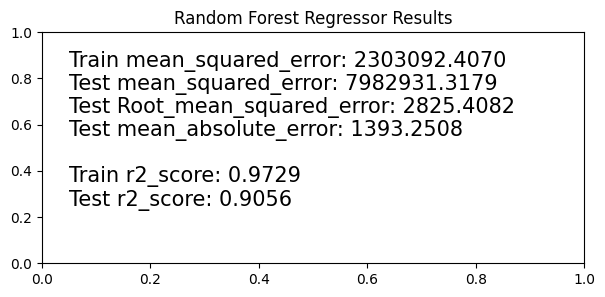


Random Forest Regressor Results

The Predicted results of Unseen Data: 

---------------------------------------|
Predicted: 41966.41 , Actual: 43212.35
Predicted: 42700.44 , Actual: 46083.40
Predicted: 53011.46 , Actual: 52442.80
Predicted: 52593.16 , Actual: 52911.10
Predicted: 50725.24 , Actual: 56364.50
Predicted: 47266.50 , Actual: 48364.90
Predicted: 45812.48 , Actual: 49984.80
Predicted: 60966.09 , Actual: 61124.75
Predicted: 39540.27 , Actual: 35864.65
Predicted: 54293.40 , Actual: 53218.25
Predicted: 43529.36 , Actual: 44945.60
Predicted: 45777.01 , Actual: 42420.00
Predicted: 51555.20 , Actual: 51639.10
Predicted: 44349.66 , Actual: 43739.70
Predicted: 41243.53 , Actual: 40373.85
Predicted: 47427.59 , Actual: 45759.75
Predicted: 49954.54 , Actual: 51960.50
Predicted: 61582.62 , Actual: 65408.15
Predicted: 38454.32 , Actual: 39111.60
Predicted: 50663.77 , Actual: 49817.80


In [10]:
starttime=time.perf_counter()

modelR=RandomForestRegressor(
                              max_depth=10,
                              n_jobs=-1,
                              n_estimators=100,
                              max_features='sqrt',
                              random_state=42,
                              min_samples_split=5,
    )

modelR.fit(xtrain,ytrain)
train_predictions = modelR.predict(xtrain)
test_predictions =modelR.predict(xtest)

train_mse = mean_squared_error(ytrain, train_predictions)
test_mse = mean_squared_error(ytest, test_predictions)
test_rmse=np.sqrt(test_mse)
train_r2 = r2_score(ytrain, train_predictions)
test_r2 = r2_score(ytest, test_predictions)

print('Time :=',format(time.perf_counter()-starttime,'.2f'),' seconds')
plt.figure(figsize=(7,3))
plt.title('Random Forest Regressor Results')
plt.text(0.05, 0.85, f"Train mean_squared_error: {train_mse  :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.75, f"Test mean_squared_error: { test_mse :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.65, f"Test Root_mean_squared_error: {test_rmse  :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.55, f"Test mean_absolute_error: { test_mae :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.35, f"Train r2_score: {train_r2 :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.25, f"Test r2_score: {test_r2 :.4f}", fontsize=15, ha='left')
plt.show()


print('\nRandom Forest Regressor Results')
print('\nThe Predicted results of Unseen Data: \n')
print('---------------------------------------|')
for i in range(20):
    print('Predicted:', format(test_predictions[i],'.2f'), ', Actual:',  format(ytest.iloc[i],'.2f'))

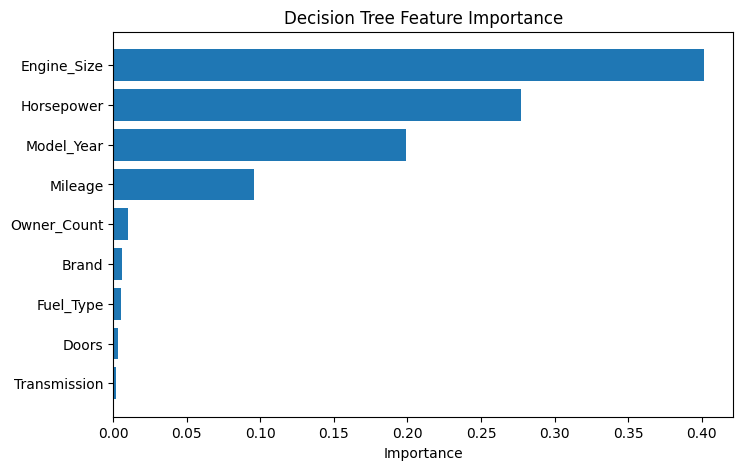

In [11]:
feature_importance = pd.DataFrame({
    'Feature': xtrain.columns,
    'Importance': modelD.feature_importances_
}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(8,5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Decision Tree Feature Importance')
plt.show()

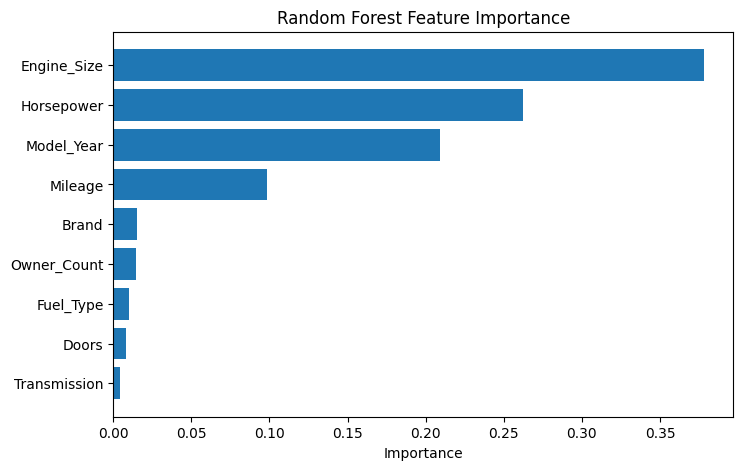

In [12]:
feature_importance = pd.DataFrame({
    'Feature': xtrain.columns,
    'Importance': modelR.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.show()

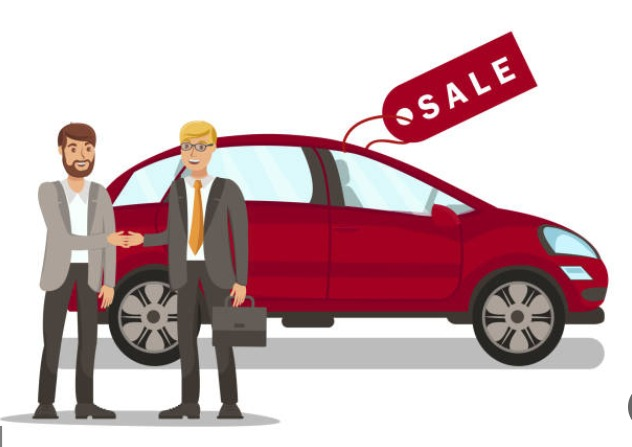